# Titanic Survival Prediction

## Project Overview

This project analyzes passenger information from the Titanic dataset and builds a machine learning model to predict passenger survival.

The analysis begins with exploratory data analysis and data cleaning, followed by feature engineering and the development of a classification model.

### Objectives

- Understand the characteristics of Titanic passengers
- Analyze factors associated with survival
- Perform data cleaning and preprocessing
- Create useful features for prediction
- Train a classification model
- Evaluate model performance
- Generate survival predictions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 891
Jumlah kolom: 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Age,177
Cabin,687
Embarked,2


In [ ]:
survival_count = df["Survived"].value_counts()

survival_count

,count
Survived,
0,549
1,342


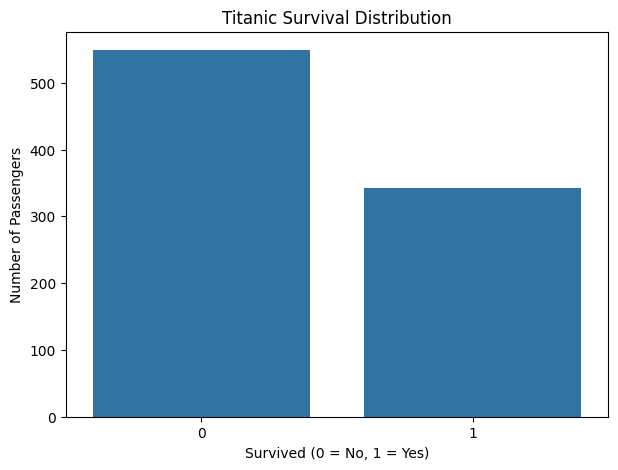

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

Apakah survival berbeda berdasarkan gender?

In [ ]:
gender_survival = (
    df.groupby("Sex")["Survived"]
    .mean()
    .sort_values(ascending=False)
)

gender_survival

,Survived
Sex,
female,0.742038
male,0.188908


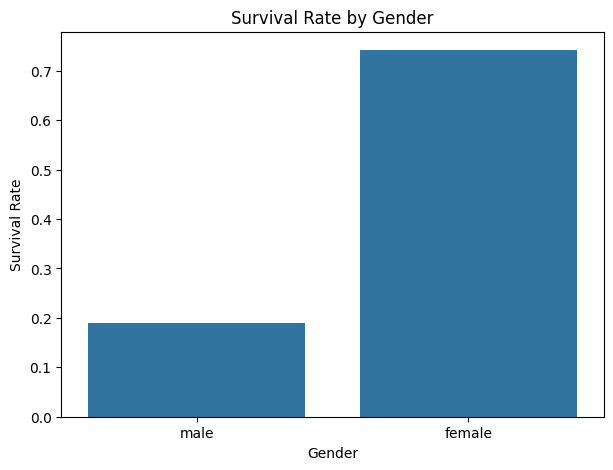

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    errorbar=None
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
class_survival = (
    df.groupby("Pclass")["Survived"]
    .mean()
)

class_survival

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


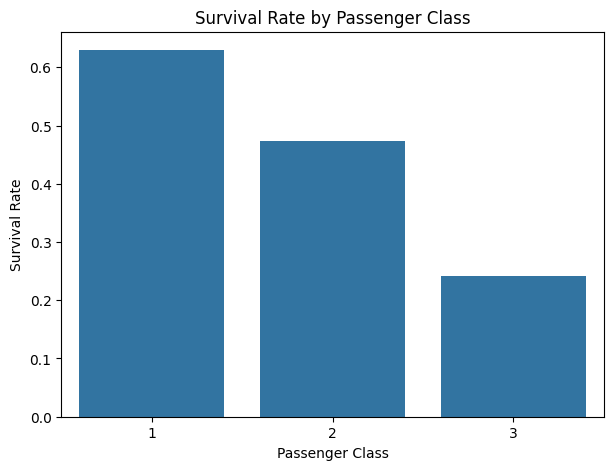

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    errorbar=None
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## 3. Data Cleaning

Missing values were identified in the Age, Cabin, and Embarked columns. The Age column is filled using its median value, while missing Embarked values are replaced using the most frequent category. The Cabin column is removed because most of its values are missing.

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df = df.drop(columns=["Cabin"])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 4. Feature Engineering

Features related to passenger characteristics and travel information are selected for model training. Categorical variables such as Sex and Embarked are converted into numerical representations.

In [ ]:
df_model = df[
    [
        "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
].copy()

In [ ]:
df_model = pd.get_dummies(
    df_model,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [ ]:
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

In [ ]:
print("Jumlah fitur:", X.shape[1])
print("Jumlah target:", y.shape[0])

Jumlah fitur: 8
Jumlah target: 891


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


## 5. Machine Learning Model

Logistic Regression is used as the baseline classification model to predict whether a passenger survived the Titanic disaster.

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [ ]:
print("Actual:")
print(y_test.values[:20])

Actual:
[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.45%


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[98, 12],
       [23, 46]])

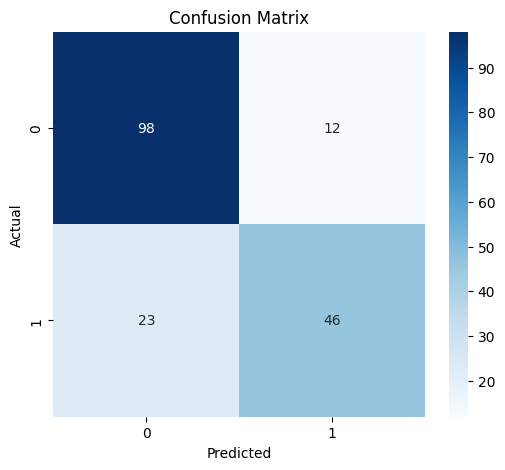

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = (
    feature_importance
    .sort_values("Coefficient", ascending=False)
)

feature_importance

,Feature,Coefficient
6,Embarked_Q,0.278320
4,Fare,0.002255
1,Age,-0.038464
3,Parch,-0.071496
2,SibSp,-0.243809
7,Embarked_S,-0.381616
0,Pclass,-1.090476
5,Sex_male,-2.555755


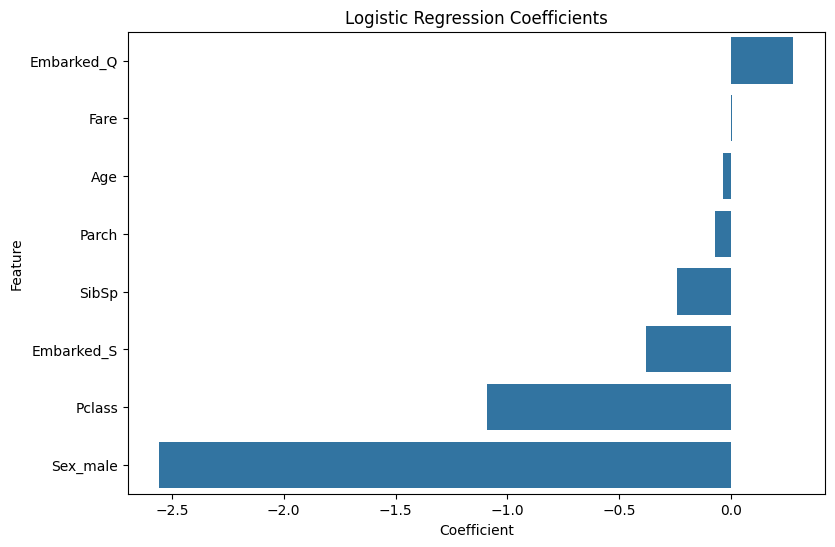

In [ ]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred_tree = tree_model.predict(X_test)

In [ ]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")

Decision Tree Accuracy: 78.77%


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.787709


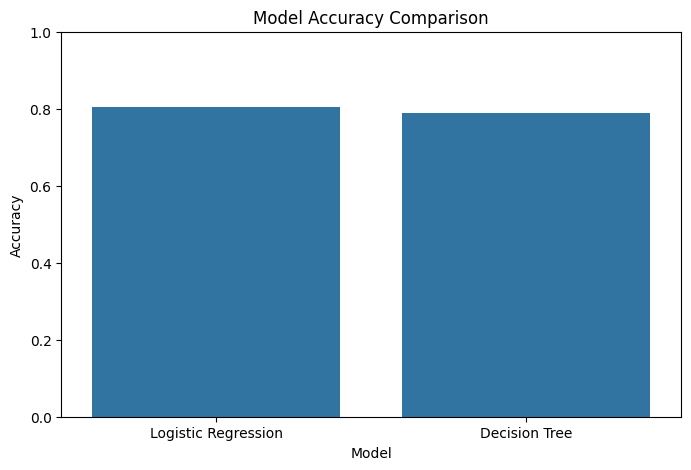

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy",
    errorbar=None
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179



## 7. Final Model Evaluation

Two classification models were evaluated: Logistic Regression and Decision Tree. Logistic Regression achieved an accuracy of 80.45%, while Decision Tree achieved 78.77%.

Based on the comparison, Logistic Regression was selected as the final model because it achieved higher accuracy and better recall for the survival class.

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,0
6,1,1
7,0,0
8,0,0
9,0,0


In [ ]:
correct_predictions = (y_test.values == y_pred).sum()
total_predictions = len(y_test)

print(f"Correct Predictions: {correct_predictions}")
print(f"Total Predictions: {total_predictions}")
print(f"Accuracy: {correct_predictions / total_predictions:.2%}")

Correct Predictions: 144
Total Predictions: 179
Accuracy: 80.45%


## 8. Key Findings

### 1. Survival Pattern

The dataset contains 342 surviving passengers and 549 non-surviving passengers. The overall survival rate was approximately 38.38%.

### 2. Gender

Female passengers had a substantially higher survival rate of 74.20%, compared with 18.89% for male passengers.

### 3. Passenger Class

Passengers in first class had the highest survival rate at approximately 62.96%, followed by second class at 47.28% and third class at 24.24%.

### 4. Logistic Regression

The Logistic Regression model achieved an accuracy of 80.45%. For the survival class, the model achieved a precision of 79%, recall of 67%, and F1-score of 72%.

### 5. Decision Tree

The Decision Tree achieved an accuracy of 78.77%. Although it achieved higher precision for the survival class at 84%, its recall was lower at 55%.

### 6. Model Selection

Logistic Regression was selected as the final model because it provided higher overall accuracy and better recall for the survival class compared with the Decision Tree model.

## 9. Conclusion

This project analyzed the Titanic passenger dataset and developed machine learning models to predict passenger survival.

Exploratory analysis showed substantial differences in survival rates based on gender and passenger class. Female passengers and passengers in higher classes had considerably higher survival rates than male passengers and passengers in lower classes.

Two classification models were evaluated: Logistic Regression and Decision Tree. Logistic Regression achieved an accuracy of 80.45%, slightly outperforming Decision Tree at 78.77%. Logistic Regression was therefore selected as the final model.

The results demonstrate how data analysis, feature engineering, and classification algorithms can be combined to identify patterns and make predictions from historical passenger data.